## Dataset Shape and Any Empty Values

In [275]:
import pandas as pd

df = pd.read_parquet("../data/raw/energy_generation_dataset.parquet")

df.shape
df.head()
df.columns
df.dtypes
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000776 entries, 0 to 1000775
Data columns (total 49 columns):
 #   Column                            Non-Null Count    Dtype              
---  ------                            --------------    -----              
 0   Plant_code                        1000776 non-null  category           
 1   Plant                             1000776 non-null  object             
 2   Technology                        1000776 non-null  category           
 3   Tecnologia                        1000776 non-null  category           
 4   Classification                    1000776 non-null  category           
 5   Subsystem                         1000776 non-null  category           
 6   Datetime                          1000776 non-null  datetime64[us]     
 7   Datetime_UTC                      1000776 non-null  datetime64[us, UTC]
 8   Date                              1000776 non-null  datetime64[us]     
 9   Year                              1

Plant_code                          0
Plant                               0
Technology                          0
Tecnologia                          0
Classification                      0
Subsystem                           0
Datetime                            0
Datetime_UTC                        0
Date                                0
Year                                0
Month                               0
Day                                 0
Hour                                0
Day_of_week                         0
Day_name                            0
Weekend                             0
Day_sin                             0
Day_cos                             0
Generation_MWh                      0
Plant_latitude                      0
Plant_longitude                     0
UTM_Easting                         0
UTM_Northing                        0
UTM_Zone                            0
ERA5_latitude                       0
ERA5_longitude                      0
ERA5_distanc

In [276]:
df["Technology"].value_counts()
df["Subsystem"].value_counts()

Subsystem
SIC    1000776
Name: count, dtype: int64

In [277]:
df["Datetime"].min()
df["Datetime"].max()

Timestamp('2026-04-30 23:00:00')

## Column Dictionary

Left blank where the meaning could not be confidently determined from the data alone.

| # | Column | Meaning |
|---|--------|---------|
| 0 | `Plant_code` | Unique identifier for the power plant (49 unique values). |
| 1 | `Plant` | Human-readable name of the power plant. |
| 2 | `Technology` | Generation technology category, in English: Biomass, Mini run-of-river hydropower, Reservoir hydropower, Run-of-river hydropower, Solar photovoltaic, Wind. |
| 3 | `Tecnologia` | Same technology category as `Technology`, labeled in Spanish (e.g. "Hidráulica de Pasada"). |
| 4 | `Classification` | Chilean regulatory classification: "ERNC" (Non-Conventional Renewable Energy) vs "Convencional" (conventional); maps 1:1 with `Technology`. |
| 5 | `Subsystem` | Electrical subsystem the plant belongs to. Only value present is "SIC" (Chile's former Central Interconnected System). |
| 6 | `Datetime` | Local (Chile) timestamp of the hourly record. |
| 7 | `Datetime_UTC` | Same timestamp as `Datetime`, converted to UTC (timezone-aware). |
| 8 | `Date` | Calendar date. |
| 9 | `Year` | Year extracted from `Datetime`. |
| 10 | `Month` | Month extracted from `Datetime`. |
| 11 | `Day` | Day-of-month extracted from `Datetime`. |
| 12 | `Hour` | Hour of day (0–23) extracted from `Datetime`. |
| 13 | `Day_of_week` | Day of week as an integer, 1 = Monday ... 7 = Sunday. |
| 14 | `Day_name` | Day of week as a name (Monday ... Sunday); mirrors `Day_of_week`. |
| 15 | `Weekend` | Binary flag, 1 if Saturday/Sunday else 0. |
| 16 | `Day_sin` | Cyclical sine encoding of day-of-week: `sin(2π·(Day_of_week−1)/7)`. |
| 17 | `Day_cos` | Cyclical cosine encoding of day-of-week: `cos(2π·(Day_of_week−1)/7)`, paired with `Day_sin`. |
| 18 | `Generation_MWh` | Hourly electricity generation of the plant, in MWh — the main target variable. |
| 19 | `Plant_latitude` | Latitude of the plant's physical location. |
| 20 | `Plant_longitude` | Longitude of the plant's physical location. |
| 21 | `UTM_Easting` | Plant location's Easting coordinate in the UTM projection. |
| 22 | `UTM_Northing` | Plant location's Northing coordinate in the UTM projection. |
| 23 | `UTM_Zone` | UTM zone code (e.g. "19H") for the `UTM_Easting`/`UTM_Northing` coordinates. |
| 24 | `ERA5_latitude` | Latitude of the nearest ERA5 reanalysis weather grid cell matched to the plant. |
| 25 | `ERA5_longitude` | Longitude of the nearest ERA5 reanalysis grid cell matched to the plant. |
| 26 | `ERA5_distance_km` | Distance (km) between the plant and its matched ERA5 grid cell. |
| 27 | `Surface_pressure` | Raw ERA5 surface pressure at the grid cell/hour, in Pa. |
| 28 | `Total_precipitation` | Raw ERA5 total precipitation, in meters (ERA5 native unit). |
| 29 | `Solar_radiation` | Raw ERA5 surface downward solar radiation, accumulated J/m² over the hour. |
| 30 | `Dewpoint_temperature_2m` | Raw ERA5 dewpoint temperature at 2 m, in Kelvin. |
| 31 | `Temperature_2m` | Raw ERA5 air temperature at 2 m, in Kelvin. |
| 32 | `Wind_u10` | Raw ERA5 eastward (u) wind component at 10 m, in m/s. |
| 33 | `Wind_v10` | Raw ERA5 northward (v) wind component at 10 m, in m/s. |
| 34 | `Modified_hour` | Boolean flag for hours affected by Chile's daylight-saving-time clock change (all True values fall on the April/September DST transition dates). |
| 35 | `Source_file` | Name of the original monthly source CSV file the row was loaded from (e.g. "202401GxSEN.csv"). |
| 36 | `Surface_pressure_hPa` | `Surface_pressure` converted to hectopascals (`Surface_pressure / 100`). |
| 37 | `Total_precipitation_mm` | `Total_precipitation` converted to millimeters (`Total_precipitation × 1000`). |
| 38 | `Temperature_2m_C` | `Temperature_2m` converted to Celsius (`Temperature_2m − 273.15`). |
| 39 | `Dewpoint_temperature_2m_C` | `Dewpoint_temperature_2m` converted to Celsius. |
| 40 | `Solar_radiation_W_m2` | `Solar_radiation` converted from accumulated J/m² to average W/m² over the hour (`Solar_radiation / 3600`). |
| 41 | `Wind_speed_10m` | Scalar wind speed at 10 m computed from components: `sqrt(Wind_u10² + Wind_v10²)`. |
| 42 | `Hour_sin` | Cyclical sine encoding of hour-of-day: `sin(2π·Hour/24)`. |
| 43 | `Hour_cos` | Cyclical cosine encoding of hour-of-day: `cos(2π·Hour/24)`. |
| 44 | `Maximum net effective capacity_x` |  |
| 45 | `Maximum net effective capacity_y` | Identical to `Maximum net effective capacity` below in every row — likely the source actually used. |
| 46 | `Maximum net effective capacity` | Plant's net effective installed capacity, in MW (always equal to `..._y`; differs from `..._x` for ~61% of rows for reasons not determinable from the data alone). |
| 47 | `Maximum_gross_power_MW` | Plant's maximum gross installed power capacity, in MW. |
| 48 | `Generation_per_unit` | Hourly capacity factor: `Generation_MWh / Maximum_gross_power_MW` (verified numerically). |


## Split by Technology Into Six Datasets

In [278]:
df["Technology"].value_counts()

Technology
Run-of-river hydropower         265512
Wind                            204240
Mini run-of-river hydropower    163392
Reservoir hydropower            163392
Solar photovoltaic              163392
Biomass                          40848
Name: count, dtype: int64

In [279]:
technology_datasets = dict(tuple(df.groupby("Technology", observed=True)))

technology_datasets.keys()

dict_keys(['Biomass', 'Mini run-of-river hydropower', 'Reservoir hydropower', 'Run-of-river hydropower', 'Solar photovoltaic', 'Wind'])

In [280]:
#row counts per technology should match value_counts() above
{tech: sub.shape for tech, sub in technology_datasets.items()}

{'Biomass': (40848, 49),
 'Mini run-of-river hydropower': (163392, 49),
 'Reservoir hydropower': (163392, 49),
 'Run-of-river hydropower': (265512, 49),
 'Solar photovoltaic': (163392, 49),
 'Wind': (204240, 49)}

In [281]:
# 6 named variables to store sub-datasets for each technology
biomass = technology_datasets["Biomass"]
mini_hydro = technology_datasets["Mini run-of-river hydropower"]
reservoir_hydro = technology_datasets["Reservoir hydropower"]
run_of_river = technology_datasets["Run-of-river hydropower"]
solar = technology_datasets["Solar photovoltaic"]
wind = technology_datasets["Wind"]

## Basic Visualizations On 6 Datasets

### 1. Plot the Time Series Plot for Each of the Six Teachnology

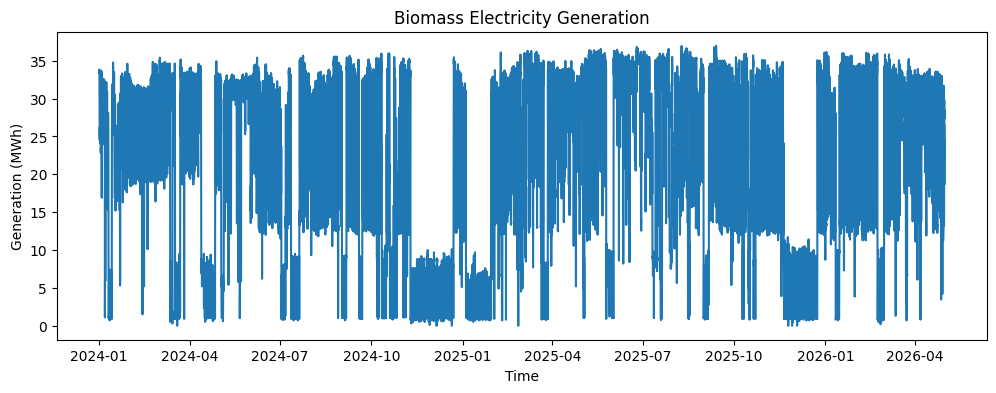

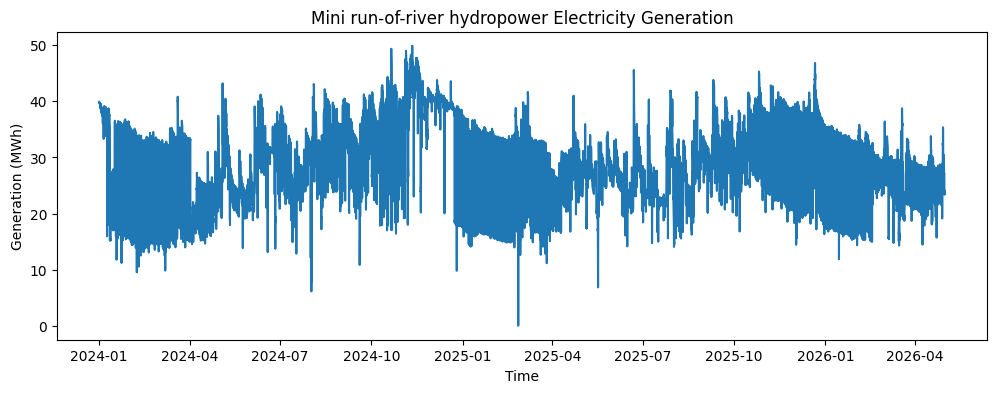

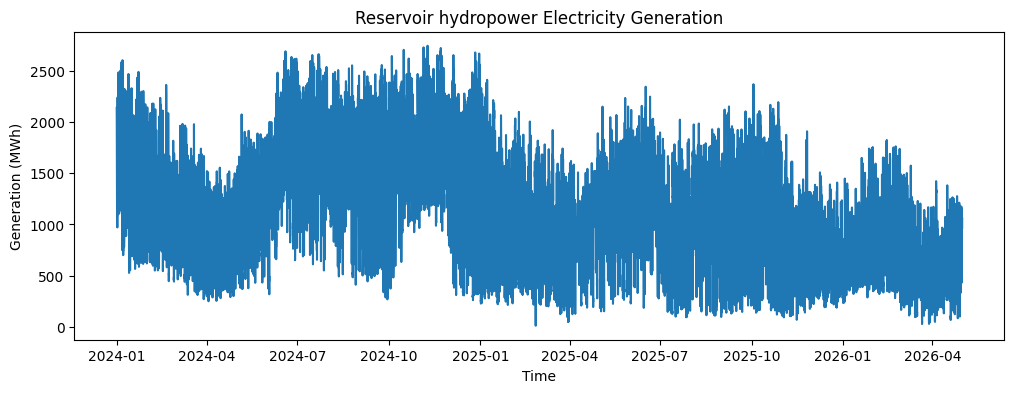

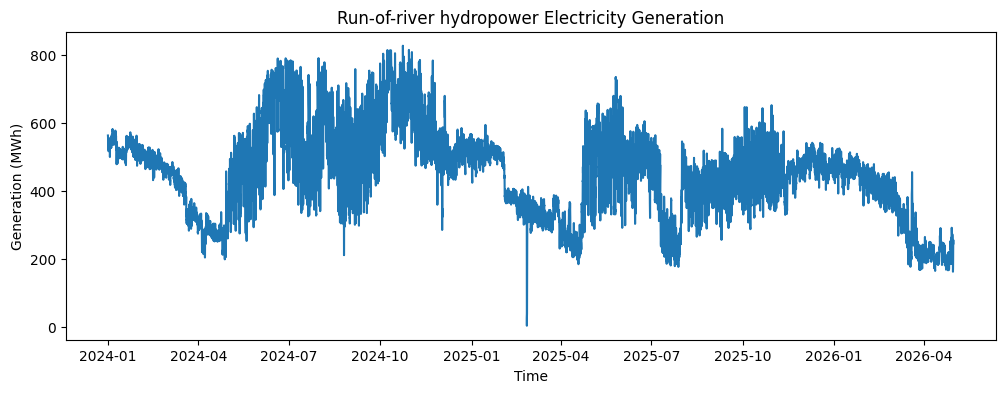

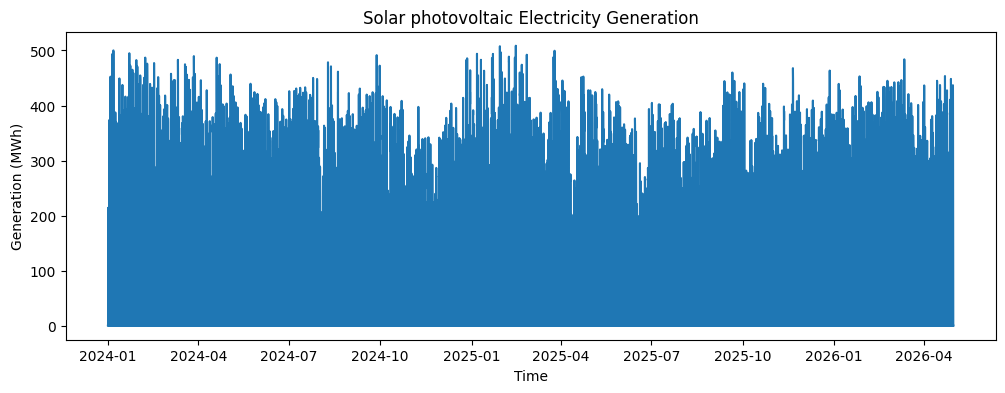

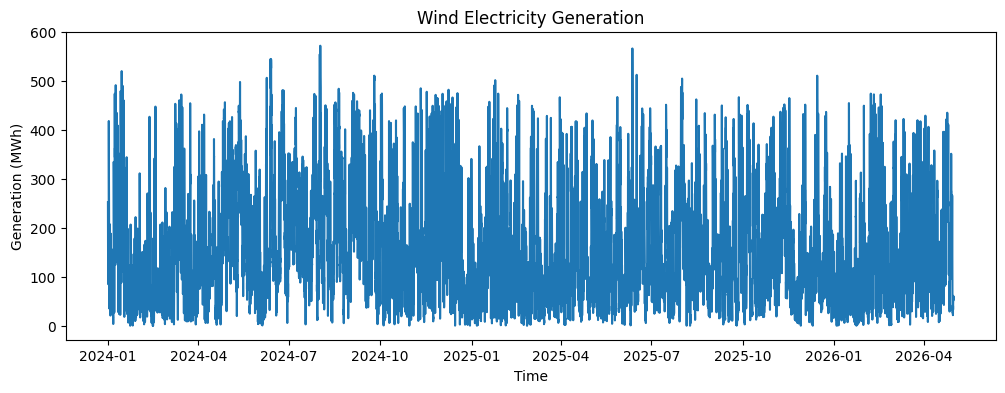

In [282]:
import pandas as pd
import matplotlib.pyplot as plt

datasets = {
    "Biomass": biomass,
    "Mini run-of-river hydropower": mini_hydro,
    "Reservoir hydropower": reservoir_hydro,
    "Run-of-river hydropower": run_of_river,
    "Solar photovoltaic": solar,
    "Wind": wind
}

for name, sub_df in datasets.items():
    # Make a copy
    temp = sub_df.copy()
    temp["Datetime"] = pd.to_datetime(temp["Datetime"])
    time_series = (
        temp.groupby("Datetime", as_index=False, sort=True)["Generation_MWh"]
        .sum()
    )
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(
        time_series["Datetime"],
        time_series["Generation_MWh"]
    )
    ax.set(
        title=f"{name} Electricity Generation",
        xlabel="Time",
        ylabel="Generation (MWh)"
    )
    plt.show()

### 2. Plot With Properly Identified Scale: Hourly

In [283]:
technology_ts = (
    df.copy()
    .assign(Datetime=lambda x: pd.to_datetime(x["Datetime"]))
    .groupby(["Technology", "Datetime"], as_index=False, sort=True, observed=True)["Generation_MWh"]
    .sum()
    .sort_values(["Technology", "Datetime"])
) # type: ignore
technology_ts.head()

,Technology,Datetime,Generation_MWh
0,Biomass,2024-01-01 00:00:00,33.368999
1,Biomass,2024-01-01 01:00:00,33.798000
2,Biomass,2024-01-01 02:00:00,33.541000
3,Biomass,2024-01-01 03:00:00,33.716999
4,Biomass,2024-01-01 04:00:00,33.808002


In [284]:
technology_ts["Technology"].unique()

['Biomass', 'Mini run-of-river hydropower', 'Reservoir hydropower', 'Run-of-river hydropower', 'Solar photovoltaic', 'Wind']
Categories (6, object): ['Biomass', 'Mini run-of-river hydropower', 'Reservoir hydropower', 'Run-of-river hydropower', 'Solar photovoltaic', 'Wind']

Incorporate all of the six time series in one plot: 

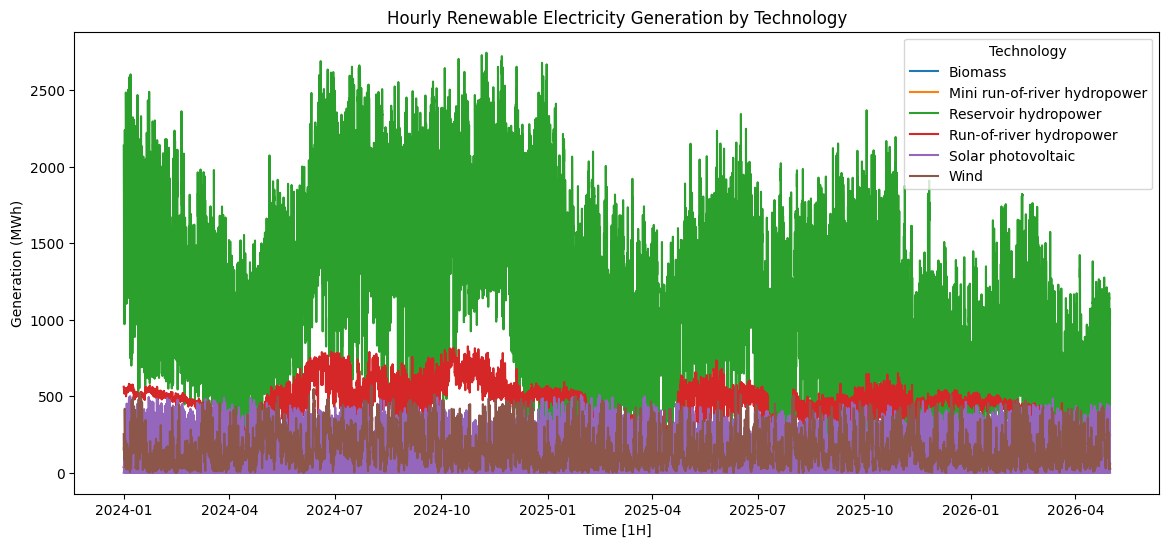

In [285]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for name, sub_df in technology_ts.groupby("Technology", observed=True):
    ax.plot(sub_df["Datetime"], sub_df["Generation_MWh"], label=name)

ax.set(
    title="Hourly Renewable Electricity Generation by Technology",
    xlabel="Time [1H]",
    ylabel="Generation (MWh)"
)
ax.legend(title="Technology")
plt.show()

The time series plot above layered six technologies to one plot, using the "hourly" scale. 

However, the time series data spans about two years (from 2023-12-31 to 2026-04-30), it's hard to observed details in this plot. Some technologies such as "Mini run-of river hydropower" has been covered completely by others. 

### 3. Zoom-in to See Detailed Pattern

1. Zoom-in One Year

In [286]:
technology_ts.groupby(
    ["Technology", technology_ts["Datetime"].dt.year]
).size()

/var/folders/r1/3d0jq7196bv2lfcz1bs_v3pm0000gp/T/ipykernel_37740/2425377689.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  technology_ts.groupby(


Technology                    Datetime
Biomass                       2024        8784
                              2025        8760
                              2026        2880
Mini run-of-river hydropower  2024        8784
                              2025        8760
                              2026        2880
Reservoir hydropower          2024        8784
                              2025        8760
                              2026        2880
Run-of-river hydropower       2024        8784
                              2025        8760
                              2026        2880
Solar photovoltaic            2024        8784
                              2025        8760
                              2026        2880
Wind                          2024        8784
                              2025        8760
                              2026        2880
dtype: int64

Choose to see year 2024, since it is most complete. 

In [287]:
year_ts = technology_ts[
    technology_ts["Datetime"].between(
        "2024-01-01",
        "2024-12-31 23:59"
    )
]

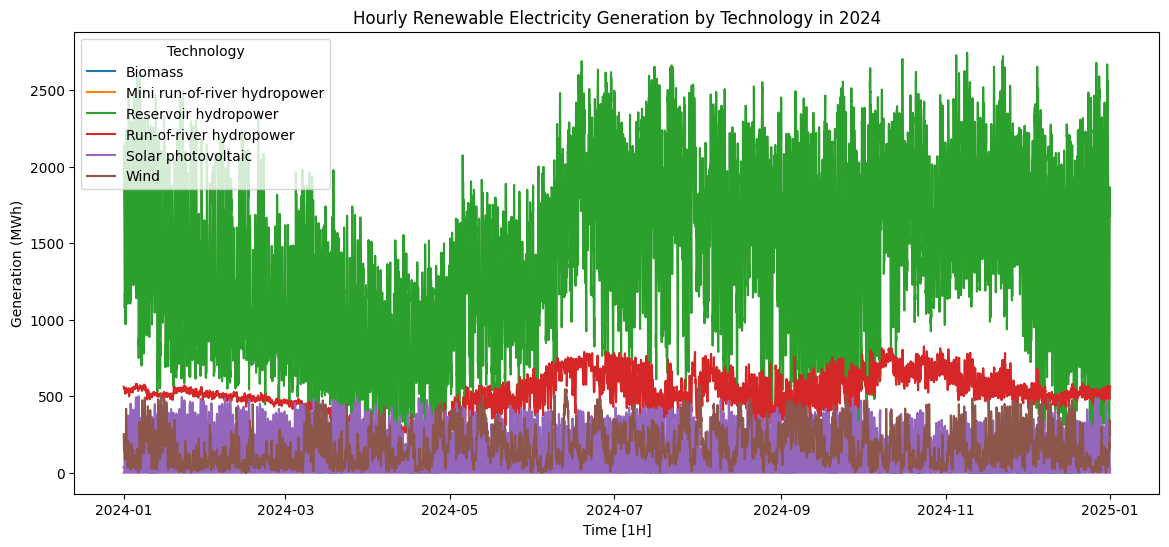

In [288]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for name, sub_df in year_ts.groupby("Technology", observed=True):
    ax.plot(sub_df["Datetime"], sub_df["Generation_MWh"], label=name)

ax.set(
    title="Hourly Renewable Electricity Generation by Technology in 2024",
    xlabel="Time [1H]",
    ylabel="Generation (MWh)"
)
ax.legend(title="Technology")
plt.show()

2. Zoom-in One Month

Picked one month every three months. This ensures that every representative months of each season are being analyzed. 

In [294]:
#January 2024
month01_ts = technology_ts[
    technology_ts["Datetime"].between(
        "2024-01-01",
        "2024-01-31 23:59"
    )
]
#April 2024
month04_ts = technology_ts[
    technology_ts["Datetime"].between(
        "2024-04-01",
        "2024-04-30 23:59"
    )
]
#July 2024
month07_ts = technology_ts[
    technology_ts["Datetime"].between(
        "2024-07-01",
        "2024-07-31 23:59"
    )
]
#October 2024
month10_ts = technology_ts[
    technology_ts["Datetime"].between(
        "2024-10-01",
        "2024-10-31 23:59"
    )
]

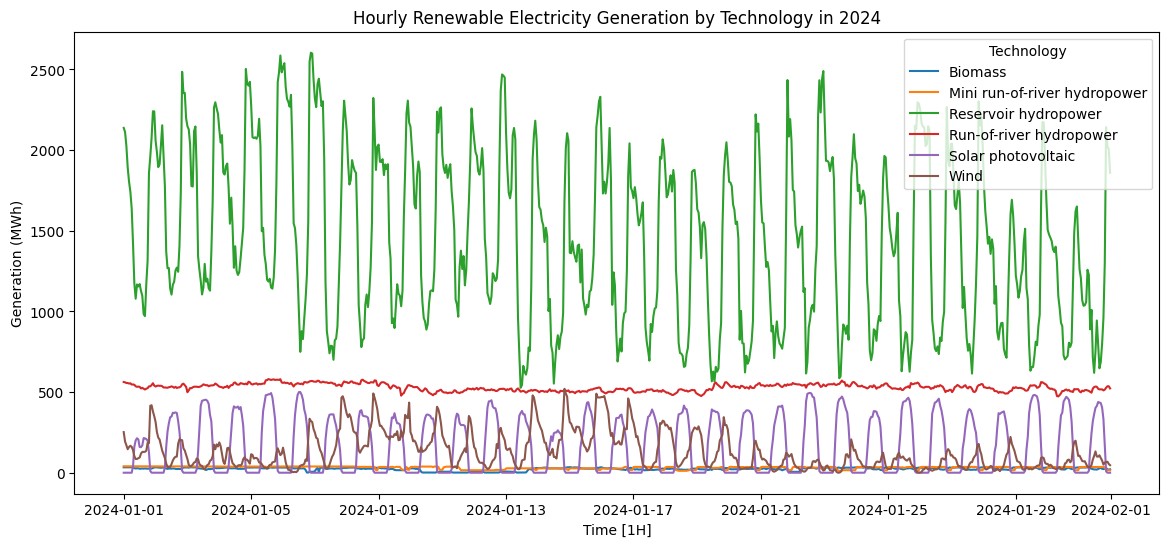

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for name, sub_df in month01_ts.groupby("Technology", observed=True):
    ax.plot(sub_df["Datetime"], sub_df["Generation_MWh"], label=name)

ax.set(
    title="Hourly Renewable Electricity Generation by Technology in January 2024",
    xlabel="Time [1H]",
    ylabel="Generation (MWh)"
)
ax.legend(title="Technology")
plt.show()

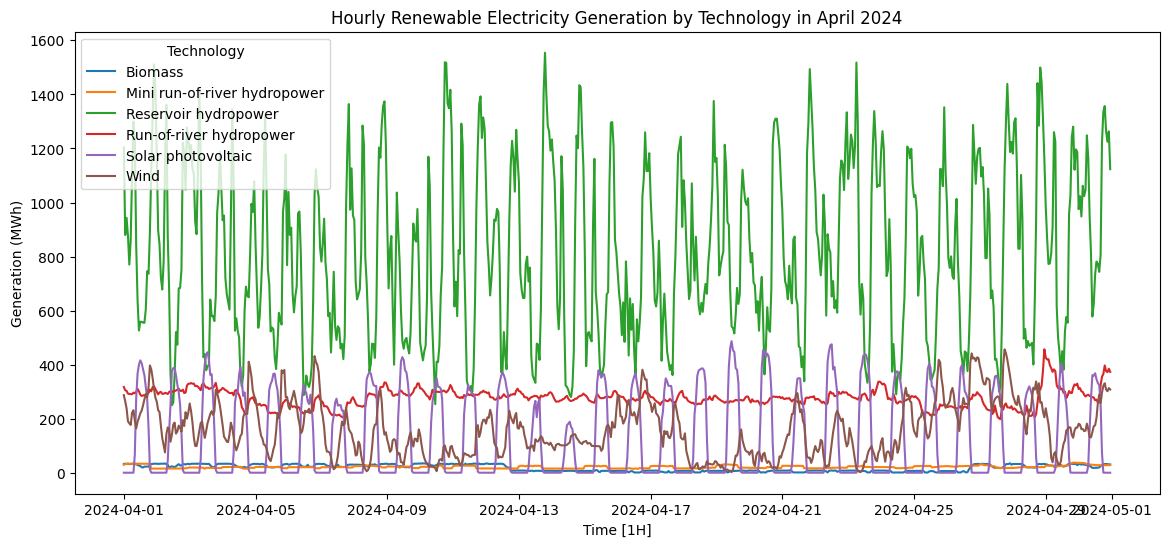

In [295]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for name, sub_df in month04_ts.groupby("Technology", observed=True):
    ax.plot(sub_df["Datetime"], sub_df["Generation_MWh"], label=name)

ax.set(
    title="Hourly Renewable Electricity Generation by Technology in April 2024",
    xlabel="Time [1H]",
    ylabel="Generation (MWh)"
)
ax.legend(title="Technology")
plt.show()

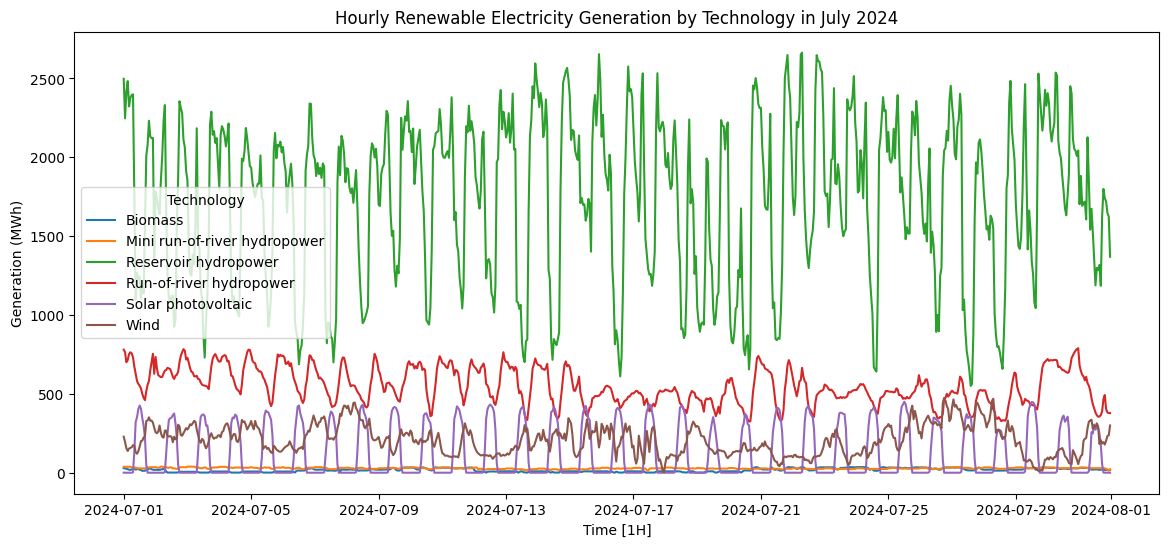

In [296]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for name, sub_df in month07_ts.groupby("Technology", observed=True):
    ax.plot(sub_df["Datetime"], sub_df["Generation_MWh"], label=name)

ax.set(
    title="Hourly Renewable Electricity Generation by Technology in July 2024",
    xlabel="Time [1H]",
    ylabel="Generation (MWh)"
)
ax.legend(title="Technology")
plt.show()

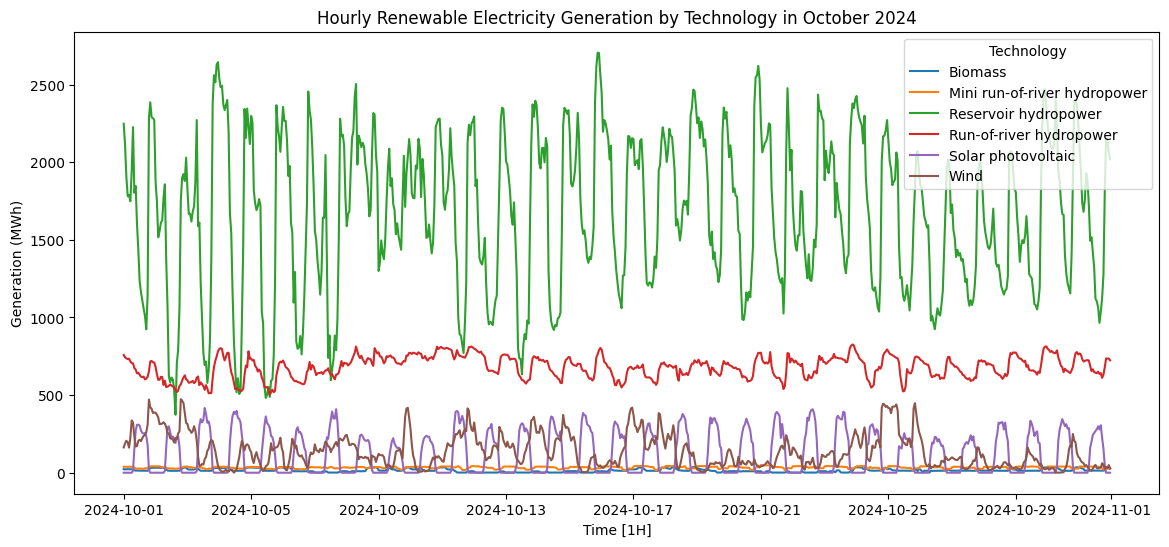

In [297]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

for name, sub_df in month10_ts.groupby("Technology", observed=True):
    ax.plot(sub_df["Datetime"], sub_df["Generation_MWh"], label=name)

ax.set(
    title="Hourly Renewable Electricity Generation by Technology in October 2024",
    xlabel="Time [1H]",
    ylabel="Generation (MWh)"
)
ax.legend(title="Technology")
plt.show()